<a href="https://colab.research.google.com/github/Salman9193/ml-finance-capstone/blob/main/banking-module/aurora_banking_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aurora Corp — Banking Module: Credit Risk & Fraud Detection
### Step 2 of the Aurora ML Finance System

**Objective:** Build an end-to-end ML pipeline to:
1. **Credit Risk** — Predict Probability of Default (PD) and classify high-risk loans
2. **Fraud Detection** — Flag anomalous transactions using supervised & unsupervised methods
3. **Recommend** approval/monitoring strategies for the lending team

**Datasets:** `loan_portfolio.csv` (100 loans) · `transactions.csv` (200 transactions)

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             classification_report, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               IsolationForest, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

import xgboost as xgb
import shap
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

print("All libraries loaded")
print(f"XGBoost: {xgb.__version__}  |  SHAP: {shap.__version__}")

All libraries loaded
XGBoost: 3.2.0  |  SHAP: 0.51.0


---
## 1. Data Loading & Initial Inspection

In [3]:
loans = pd.read_csv("loan_portfolio.csv")
txns  = pd.read_csv("transactions.csv")
txns["Timestamp"] = pd.to_datetime(txns["Timestamp"])

print("=== LOAN PORTFOLIO ===")
print(f"Shape: {loans.shape}")
print(loans.dtypes)
print()
loans.head()

=== LOAN PORTFOLIO ===
Shape: (100, 10)
Loan_ID                    int64
Customer_Type             object
Annual_Income              int64
Debt_to_Income           float64
Credit_History_Length      int64
Loan_Amount                int64
Interest_Rate            float64
Loan_Term_Months           int64
Past_Default               int64
PD                       float64
dtype: object



,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12


In [4]:
print("=== TRANSACTIONS ===")
print(f"Shape: {txns.shape}")
print(txns.dtypes)
print()
txns.head()

=== TRANSACTIONS ===
Shape: (200, 6)
Transaction_ID               int64
Customer_ID                  int64
Amount                       int64
Transaction_Type            object
Timestamp           datetime64[ns]
Fraud_Flag                   int64
dtype: object



,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag
0,1,57,35200,Withdrawal,2025-09-03 10:47:51.200706,0
1,2,16,25871,Transfer,2025-12-31 10:47:51.200738,0
2,3,56,26710,Withdrawal,2025-09-12 10:47:51.200752,0
3,4,10,5134,Withdrawal,2025-03-29 10:47:51.200763,0
4,5,30,16711,Transfer,2025-06-08 10:47:51.200773,0


In [5]:
print("LOANS — Summary Statistics")
loans.describe(include="all").round(3)

LOANS — Summary Statistics


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
count,100.000,100,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Retail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50.500,NaN,2671591.570,0.554,13.010,509767.280,9.069,34.920,0.130,0.157
std,29.011,NaN,1444021.046,0.243,7.116,273871.762,3.356,17.149,0.338,0.089
min,1.000,NaN,56790.000,0.110,1.000,11062.000,3.400,12.000,0.000,0.010
25%,25.750,NaN,1366360.750,0.372,6.000,274199.500,6.040,24.000,0.000,0.080
50%,50.500,NaN,2778969.000,0.570,14.500,544523.500,9.185,36.000,0.000,0.165
75%,75.250,NaN,3980000.750,0.780,19.000,720938.750,12.170,48.000,0.000,0.232


In [6]:
print("TRANSACTIONS — Summary Statistics")
txns.describe(include="all").round(3)

TRANSACTIONS — Summary Statistics


,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag
count,200.000,200.000,200.000,200,200,200.000
unique,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,Withdrawal,NaN,NaN
freq,NaN,NaN,NaN,69,NaN,NaN
mean,100.500,52.495,25462.710,NaN,2025-07-27 19:11:51.201649664,0.045
min,1.000,2.000,155.000,NaN,2025-01-26 10:47:51.201107,0.000
25%,50.750,30.000,13495.500,NaN,2025-04-18 04:47:51.201208576,0.000
50%,100.500,55.000,25802.000,NaN,2025-08-19 22:47:51.201696512,0.000
75%,150.250,76.250,36254.000,NaN,2025-10-26 04:47:51.201142016,0.000
max,200.000,100.000,49980.000,NaN,2026-01-25 10:47:51.200829,1.000


In [7]:
print(f"Missing values — Loans:\n{loans.isnull().sum()}")
print()
print(f"Missing values — Transactions:\n{txns.isnull().sum()}")
print()
print(f"Fraud rate in transactions: {txns['Fraud_Flag'].mean():.1%}")
print(f"Mean PD in loan portfolio : {loans['PD'].mean():.3f}")
print(f"Past default rate         : {loans['Past_Default'].mean():.1%}")

Missing values — Loans:
Loan_ID                  0
Customer_Type            0
Annual_Income            0
Debt_to_Income           0
Credit_History_Length    0
Loan_Amount              0
Interest_Rate            0
Loan_Term_Months         0
Past_Default             0
PD                       0
dtype: int64

Missing values — Transactions:
Transaction_ID      0
Customer_ID         0
Amount              0
Transaction_Type    0
Timestamp           0
Fraud_Flag          0
dtype: int64

Fraud rate in transactions: 4.5%
Mean PD in loan portfolio : 0.157
Past default rate         : 13.0%


---
## 2. Exploratory Data Analysis (EDA)

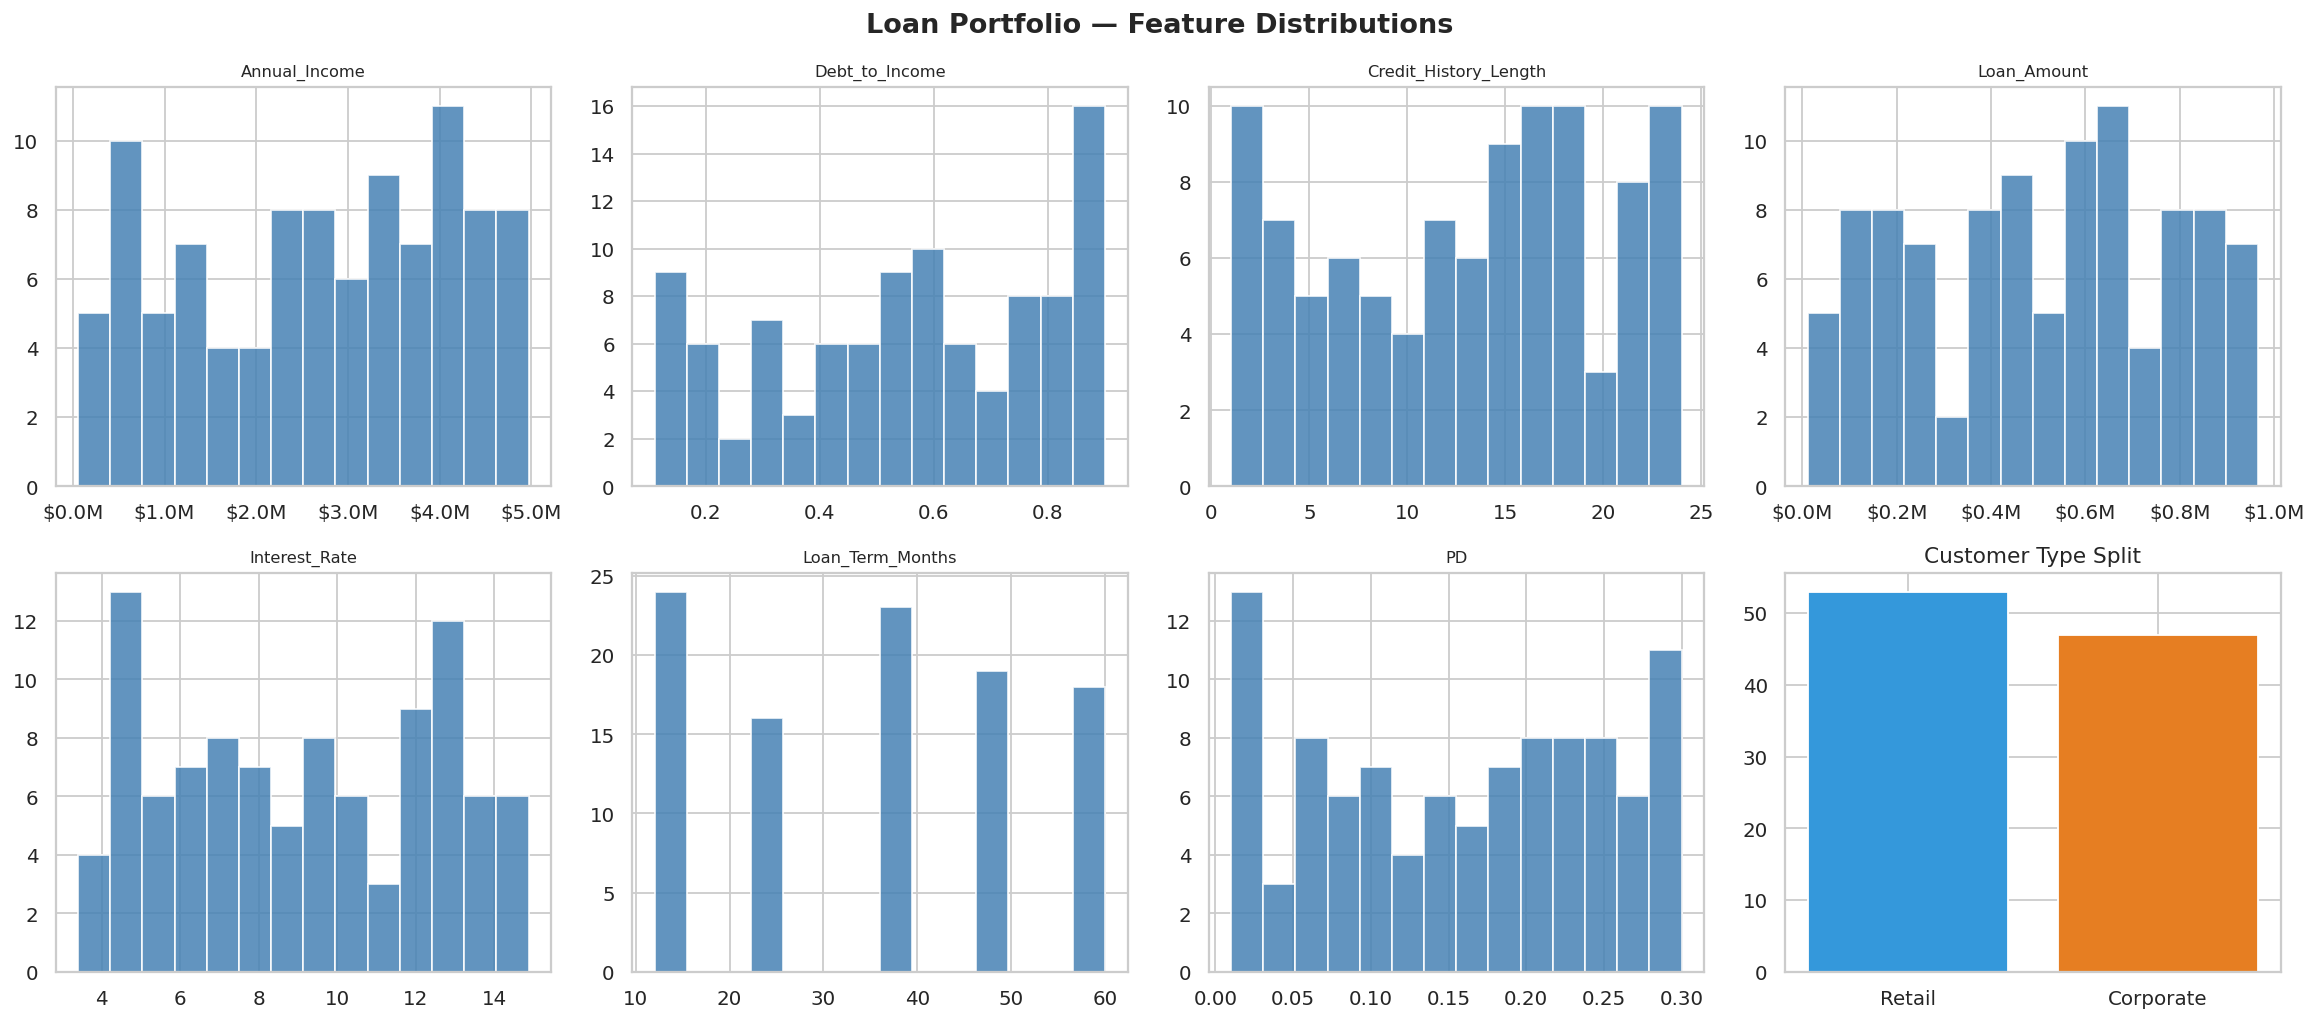

In [8]:
# ── Loan portfolio distributions ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Loan Portfolio — Feature Distributions", fontsize=15, fontweight="bold")

num_cols = ["Annual_Income","Debt_to_Income","Credit_History_Length",
            "Loan_Amount","Interest_Rate","Loan_Term_Months","PD"]

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(loans[col], bins=14, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=9)
    if col in ["Annual_Income","Loan_Amount"]:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# Customer type split
ct = loans["Customer_Type"].value_counts()
axes[1][3].bar(ct.index, ct.values, color=["#3498db","#e67e22"], edgecolor="white")
axes[1][3].set_title("Customer Type Split")

plt.tight_layout()
plt.savefig("01_loan_distributions.png", bbox_inches="tight")
plt.show()

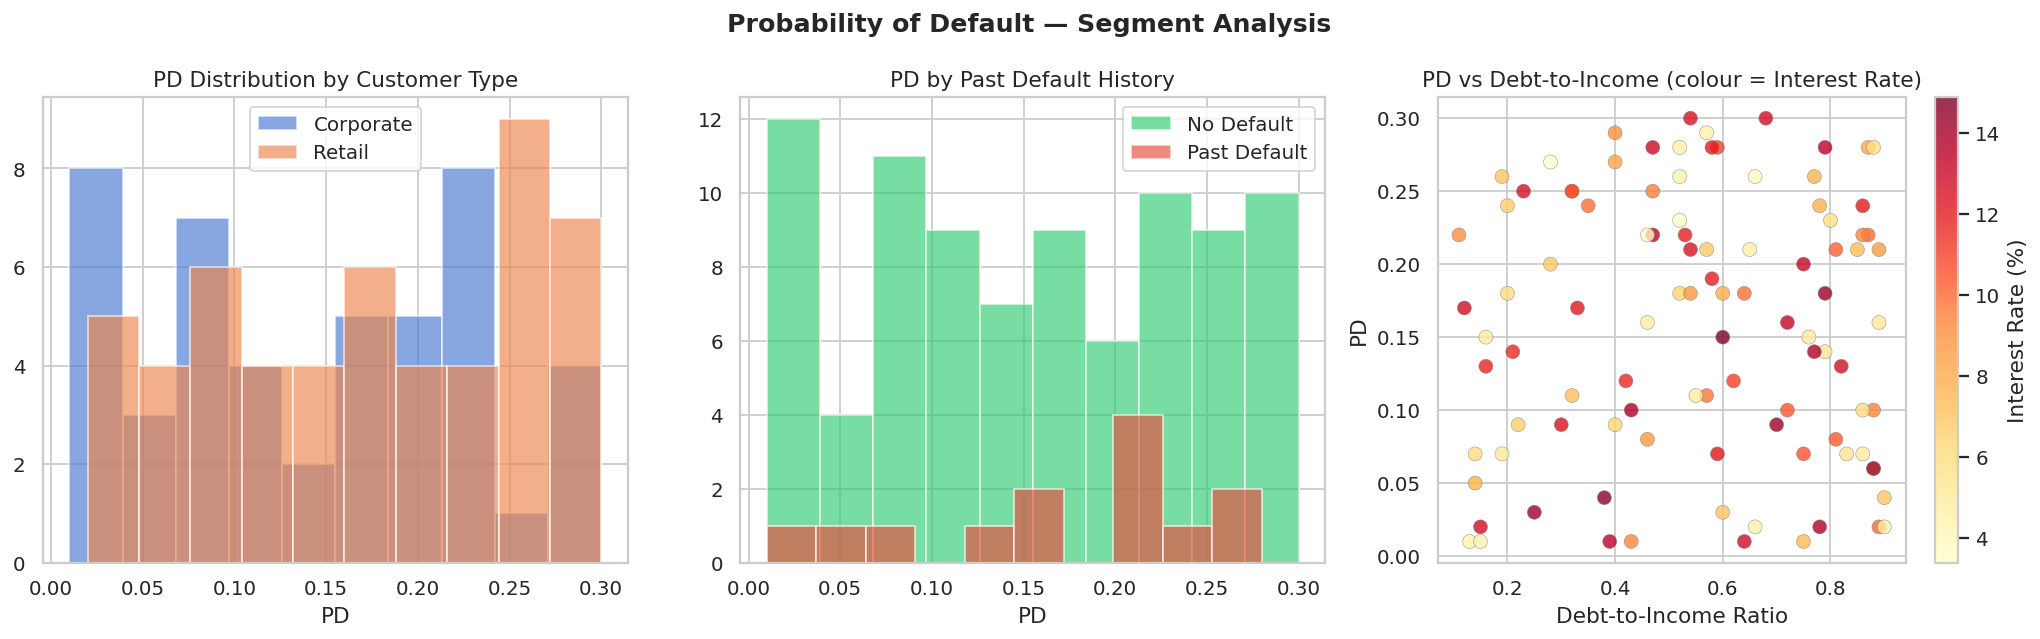

In [9]:
# ── PD analysis by segment ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Probability of Default — Segment Analysis", fontsize=14, fontweight="bold")

# PD by customer type
for ct, grp in loans.groupby("Customer_Type"):
    axes[0].hist(grp["PD"], bins=10, alpha=0.65, label=ct, edgecolor="white")
axes[0].set_title("PD Distribution by Customer Type")
axes[0].set_xlabel("PD")
axes[0].legend()

# PD by past default
for pd_val, grp in loans.groupby("Past_Default"):
    axes[1].hist(grp["PD"], bins=10, alpha=0.65,
                 label=["No Default","Past Default"][pd_val],
                 color=["#2ecc71","#e74c3c"][pd_val], edgecolor="white")
axes[1].set_title("PD by Past Default History")
axes[1].set_xlabel("PD")
axes[1].legend()

# PD vs Debt-to-Income scatter
sc = axes[2].scatter(loans["Debt_to_Income"], loans["PD"],
                     c=loans["Interest_Rate"], cmap="YlOrRd",
                     s=60, edgecolors="grey", linewidth=0.3, alpha=0.8)
axes[2].set_title("PD vs Debt-to-Income (colour = Interest Rate)")
axes[2].set_xlabel("Debt-to-Income Ratio")
axes[2].set_ylabel("PD")
fig.colorbar(sc, ax=axes[2], label="Interest Rate (%)")

plt.tight_layout()
plt.savefig("02_pd_analysis.png", bbox_inches="tight")
plt.show()

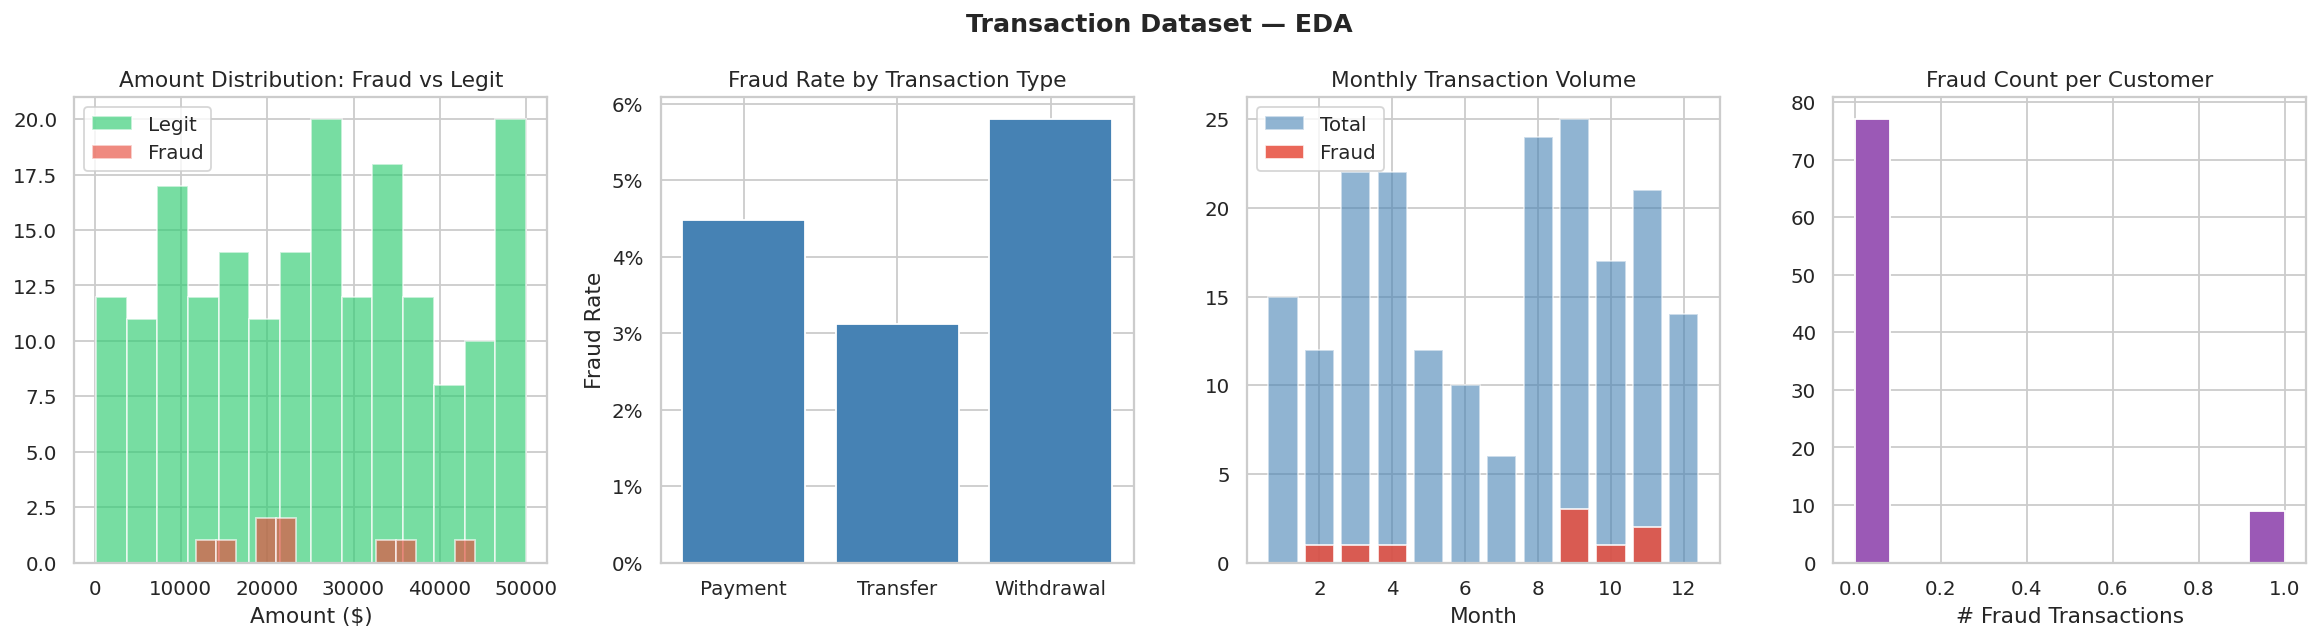

In [10]:
# ── Transaction EDA ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Transaction Dataset — EDA", fontsize=14, fontweight="bold")

# Amount distribution by fraud
for f, grp in txns.groupby("Fraud_Flag"):
    axes[0].hist(grp["Amount"], bins=14, alpha=0.65,
                 label=["Legit","Fraud"][f],
                 color=["#2ecc71","#e74c3c"][f], edgecolor="white")
axes[0].set_title("Amount Distribution: Fraud vs Legit")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

# Transaction type vs fraud rate
txn_fraud = txns.groupby("Transaction_Type")["Fraud_Flag"].agg(["mean","sum","count"])
axes[1].bar(txn_fraud.index, txn_fraud["mean"], color="steelblue", edgecolor="white")
axes[1].set_title("Fraud Rate by Transaction Type")
axes[1].set_ylabel("Fraud Rate")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Transaction volume by month
txns["Month"] = txns["Timestamp"].dt.month
monthly = txns.groupby("Month").agg(count=("Transaction_ID","count"),
                                     fraud=("Fraud_Flag","sum")).reset_index()
axes[2].bar(monthly["Month"], monthly["count"], color="steelblue",
            alpha=0.6, label="Total", edgecolor="white")
axes[2].bar(monthly["Month"], monthly["fraud"], color="#e74c3c",
            alpha=0.85, label="Fraud", edgecolor="white")
axes[2].set_title("Monthly Transaction Volume")
axes[2].set_xlabel("Month")
axes[2].legend()

# Fraud distribution across customers
cust_fraud = txns.groupby("Customer_ID")["Fraud_Flag"].sum().sort_values(ascending=False)
axes[3].hist(cust_fraud, bins=12, color="#9b59b6", edgecolor="white")
axes[3].set_title("Fraud Count per Customer")
axes[3].set_xlabel("# Fraud Transactions")

plt.tight_layout()
plt.savefig("03_transaction_eda.png", bbox_inches="tight")
plt.show()

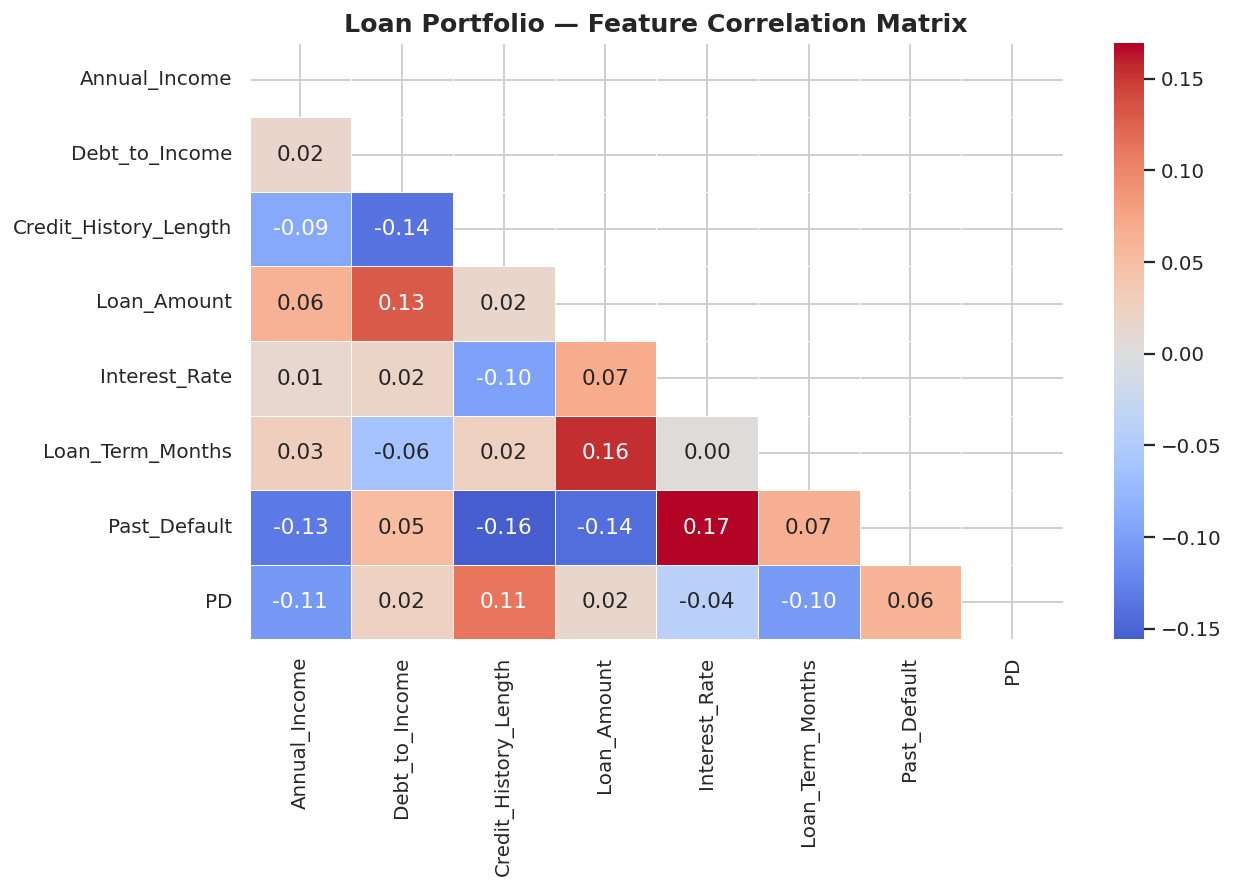

In [11]:
# ── Correlation heatmap (loans) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr_cols = ["Annual_Income","Debt_to_Income","Credit_History_Length",
             "Loan_Amount","Interest_Rate","Loan_Term_Months","Past_Default","PD"]
corr = loans[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Loan Portfolio — Feature Correlation Matrix",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("04_loan_correlation.png", bbox_inches="tight")
plt.show()

---
## 3. Feature Engineering

Derived features that encode credit risk theory:
- **Debt_Service** = (Loan_Amount × Interest_Rate/1200) / (1 − (1+r)^−n): monthly payment estimate
- **Loan_to_Income** = Loan_Amount / Annual_Income: leverage ratio
- **Risk_Class** = PD-based label: Low (<10%), Medium (10-20%), High (>20%)
- **Customer_Encoded**: Corporate=0, Retail=1

In [12]:
# ── Loan feature engineering ────────────────────────────────────────────────
def monthly_payment(row):
    r = row["Interest_Rate"] / 1200
    n = row["Loan_Term_Months"]
    P = row["Loan_Amount"]
    if r == 0:
        return P / n
    return P * r * (1 + r)**n / ((1 + r)**n - 1)

loans["Debt_Service"]    = loans.apply(monthly_payment, axis=1).round(2)
loans["Loan_to_Income"]  = (loans["Loan_Amount"] / loans["Annual_Income"]).round(4)
loans["Risk_Class"]      = pd.cut(loans["PD"], bins=[-0.01, 0.10, 0.20, 1.0],
                                   labels=["Low","Medium","High"])
loans["Customer_Enc"]    = LabelEncoder().fit_transform(loans["Customer_Type"])

# ── Transaction feature engineering ─────────────────────────────────────────
txns["Hour"]          = txns["Timestamp"].dt.hour
txns["DayOfWeek"]     = txns["Timestamp"].dt.dayofweek
txns["IsWeekend"]     = (txns["DayOfWeek"] >= 5).astype(int)
txns["IsNight"]       = ((txns["Hour"] < 6) | (txns["Hour"] >= 22)).astype(int)
txn_enc               = LabelEncoder()
txns["TxnType_Enc"]   = txn_enc.fit_transform(txns["Transaction_Type"])

# Amount z-score per transaction type (detects unusually large amounts)
txns["Amount_Zscore"] = txns.groupby("Transaction_Type")["Amount"].transform(
    lambda x: (x - x.mean()) / x.std())

# Customer-level aggregates — transaction velocity features
cust_agg = txns.groupby("Customer_ID").agg(
    Txn_Count    = ("Transaction_ID", "count"),
    Avg_Amount   = ("Amount", "mean"),
    Max_Amount   = ("Amount", "max"),
    Fraud_History= ("Fraud_Flag", "sum")
).reset_index()
txns = txns.merge(cust_agg, on="Customer_ID", how="left")

print("Loan features added:", ["Debt_Service","Loan_to_Income","Risk_Class","Customer_Enc"])
print("Txn  features added:", ["Hour","DayOfWeek","IsWeekend","IsNight",
                                "TxnType_Enc","Amount_Zscore",
                                "Txn_Count","Avg_Amount","Max_Amount","Fraud_History"])
print()
print("Risk class distribution:")
print(loans["Risk_Class"].value_counts())

Loan features added: ['Debt_Service', 'Loan_to_Income', 'Risk_Class', 'Customer_Enc']
Txn  features added: ['Hour', 'DayOfWeek', 'IsWeekend', 'IsNight', 'TxnType_Enc', 'Amount_Zscore', 'Txn_Count', 'Avg_Amount', 'Max_Amount', 'Fraud_History']

Risk class distribution:
Risk_Class
High      39
Low       34
Medium    27
Name: count, dtype: int64


---
## 4. Credit Risk — Part A: Regression (Predicting PD Continuously)

We first treat PD as a **continuous target** and regress it. This gives a precise risk score
for each loan — more granular than a binary classify-as-default decision.

In [13]:
REG_FEATURES = ["Annual_Income","Debt_to_Income","Credit_History_Length",
                 "Loan_Amount","Interest_Rate","Loan_Term_Months",
                 "Past_Default","Customer_Enc","Debt_Service","Loan_to_Income"]

X_reg = loans[REG_FEATURES]
y_reg = loans["PD"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_r)}  |  Test: {len(X_test_r)}")
print(f"PD range: {y_reg.min():.3f}  →  {y_reg.max():.3f}")

Train: 80  |  Test: 20
PD range: 0.010  →  0.300


In [14]:
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.04,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0)
rf_reg  = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
lr_reg  = LinearRegression()

reg_results = {}
for name, model in [("XGBoost", xgb_reg), ("Random Forest", rf_reg), ("Linear Reg", lr_reg)]:
    model.fit(X_train_r, y_train_r)
    preds  = model.predict(X_test_r)
    mae    = mean_absolute_error(y_test_r, preds)
    rmse   = mean_squared_error(y_test_r, preds) ** 0.5
    r2     = r2_score(y_test_r, preds)
    cv_r2  = cross_val_score(model, X_reg, y_reg, cv=5, scoring="r2").mean()
    reg_results[name] = {"model": model, "preds": preds,
                          "MAE": mae, "RMSE": rmse, "R2": r2, "CV_R2": cv_r2}
    print(f"{name:15s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | 5-CV R²: {cv_r2:.4f}")

XGBoost         | MAE: 0.0682 | RMSE: 0.0793 | R²: 0.2004 | 5-CV R²: -0.2792
Random Forest   | MAE: 0.0705 | RMSE: 0.0798 | R²: 0.1890 | 5-CV R²: -0.0865
Linear Reg      | MAE: 0.0861 | RMSE: 0.0913 | R²: -0.0604 | 5-CV R²: -0.2214


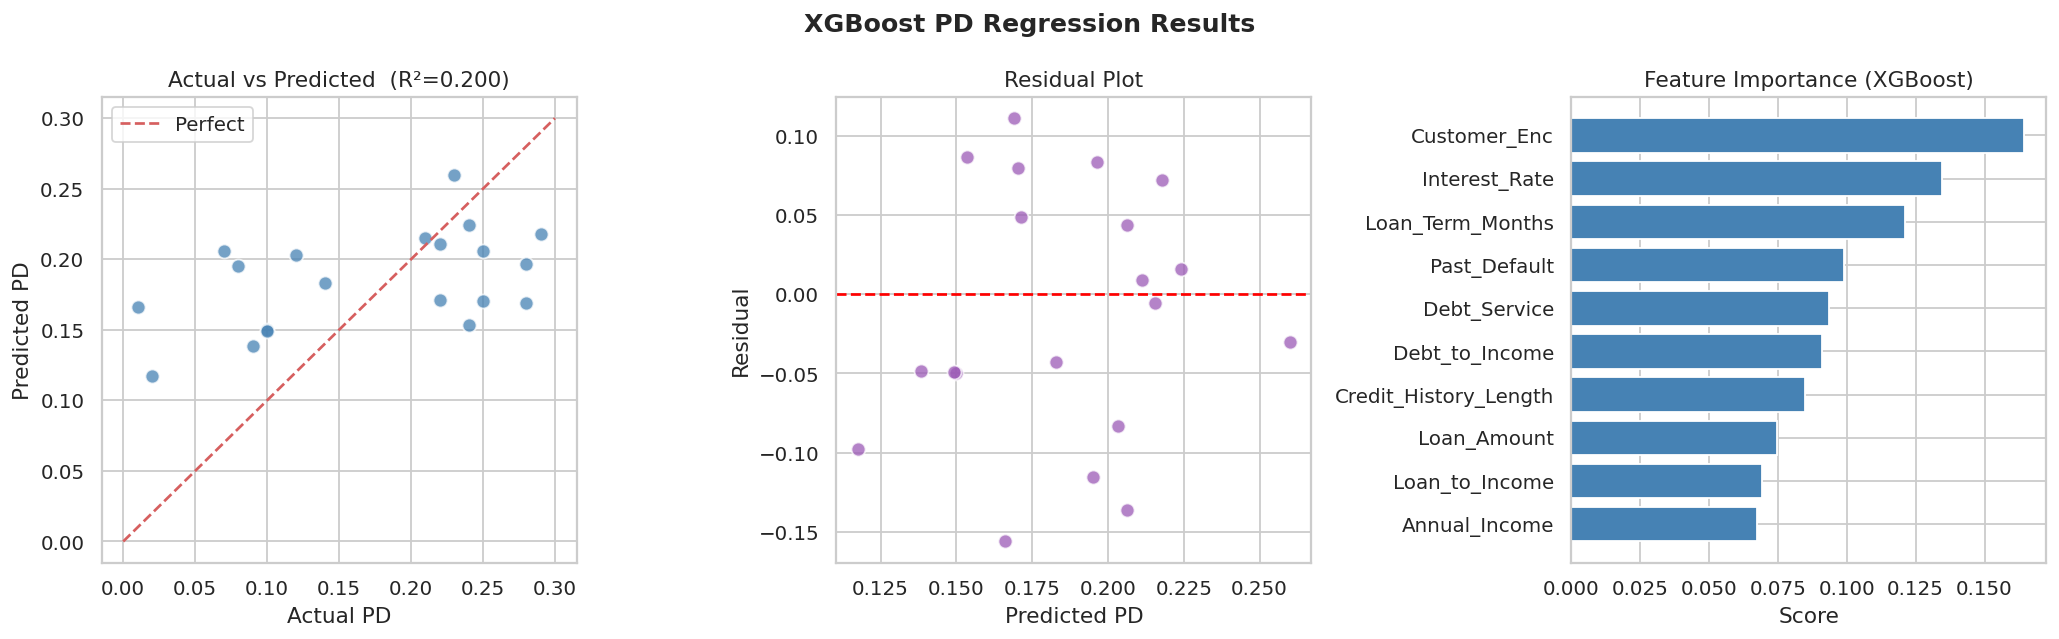

In [15]:
y_pred_r = reg_results["XGBoost"]["preds"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("XGBoost PD Regression Results", fontsize=14, fontweight="bold")

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_r, s=60, alpha=0.75,
                color="steelblue", edgecolors="white")
lims = [min(y_test_r.min(), y_pred_r.min())-0.01,
        max(y_test_r.max(), y_pred_r.max())+0.01]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual PD")
axes[0].set_ylabel("Predicted PD")
axes[0].set_title(f"Actual vs Predicted  (R²={reg_results['XGBoost']['R2']:.3f})")
axes[0].legend()

# Residuals
residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r, residuals, s=60, alpha=0.75, color="#9b59b6", edgecolors="white")
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Predicted PD")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

# Feature importances
fi = pd.Series(xgb_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=True)
axes[2].barh(fi.index, fi.values, color="steelblue", edgecolor="white")
axes[2].set_title("Feature Importance (XGBoost)")
axes[2].set_xlabel("Score")

plt.tight_layout()
plt.savefig("05_pd_regression.png", bbox_inches="tight")
plt.show()

---
## 5. Credit Risk — Part B: Classification (High-Risk Flag)

We binarise: **High Risk = 1** if PD > 0.20, else **Low/Medium Risk = 0**.
This is the actionable flag the lending team sees — *approve, review, or decline*.
We use class_weight='balanced' to handle the moderate imbalance (~30% high-risk).

In [16]:
loans["High_Risk"] = (loans["PD"] > 0.20).astype(int)
print(f"High-risk loans: {loans['High_Risk'].sum()} / {len(loans)} ({loans['High_Risk'].mean():.1%})")

CLF_FEATURES = REG_FEATURES + ["Debt_Service", "Loan_to_Income"] if "Debt_Service" not in REG_FEATURES else REG_FEATURES

X_clf = loans[CLF_FEATURES]
y_clf = loans["High_Risk"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

print(f"Train: {len(X_train_c)}  |  Test: {len(X_test_c)}")
print(f"Train high-risk rate: {y_train_c.mean():.1%}")

High-risk loans: 39 / 100 (39.0%)
Train: 80  |  Test: 20
Train high-risk rate: 38.8%


In [17]:
xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.04,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric="logloss", random_state=42, verbosity=0,
                              scale_pos_weight=(y_clf==0).sum()/(y_clf==1).sum())
rf_clf  = RandomForestClassifier(n_estimators=300, max_depth=6,
                                  class_weight="balanced", random_state=42)
lr_clf  = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)

clf_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("XGBoost", xgb_clf), ("Random Forest", rf_clf), ("Logistic Reg", lr_clf)]:
    model.fit(X_train_c, y_train_c)
    preds  = model.predict(X_test_c)
    probs  = model.predict_proba(X_test_c)[:, 1]
    auc    = roc_auc_score(y_test_c, probs)
    ap     = average_precision_score(y_test_c, probs)
    cv_auc = cross_val_score(model, X_clf, y_clf, cv=skf, scoring="roc_auc").mean()
    clf_results[name] = {"model": model, "preds": preds, "probs": probs,
                          "AUC": auc, "AP": ap, "CV_AUC": cv_auc}
    print(f"{name:15s} | AUC: {auc:.4f} | Avg Precision: {ap:.4f} | 5-CV AUC: {cv_auc:.4f}")

XGBoost         | AUC: 0.5104 | Avg Precision: 0.5351 | 5-CV AUC: 0.5534
Random Forest   | AUC: 0.6354 | Avg Precision: 0.5632 | 5-CV AUC: 0.5974
Logistic Reg    | AUC: 0.4792 | Avg Precision: 0.4324 | 5-CV AUC: 0.5714


XGBoost — Classification Report (High-Risk Loans)
              precision    recall  f1-score   support

Low/Med Risk       0.62      0.83      0.71        12
   High Risk       0.50      0.25      0.33         8

    accuracy                           0.60        20
   macro avg       0.56      0.54      0.52        20
weighted avg       0.57      0.60      0.56        20



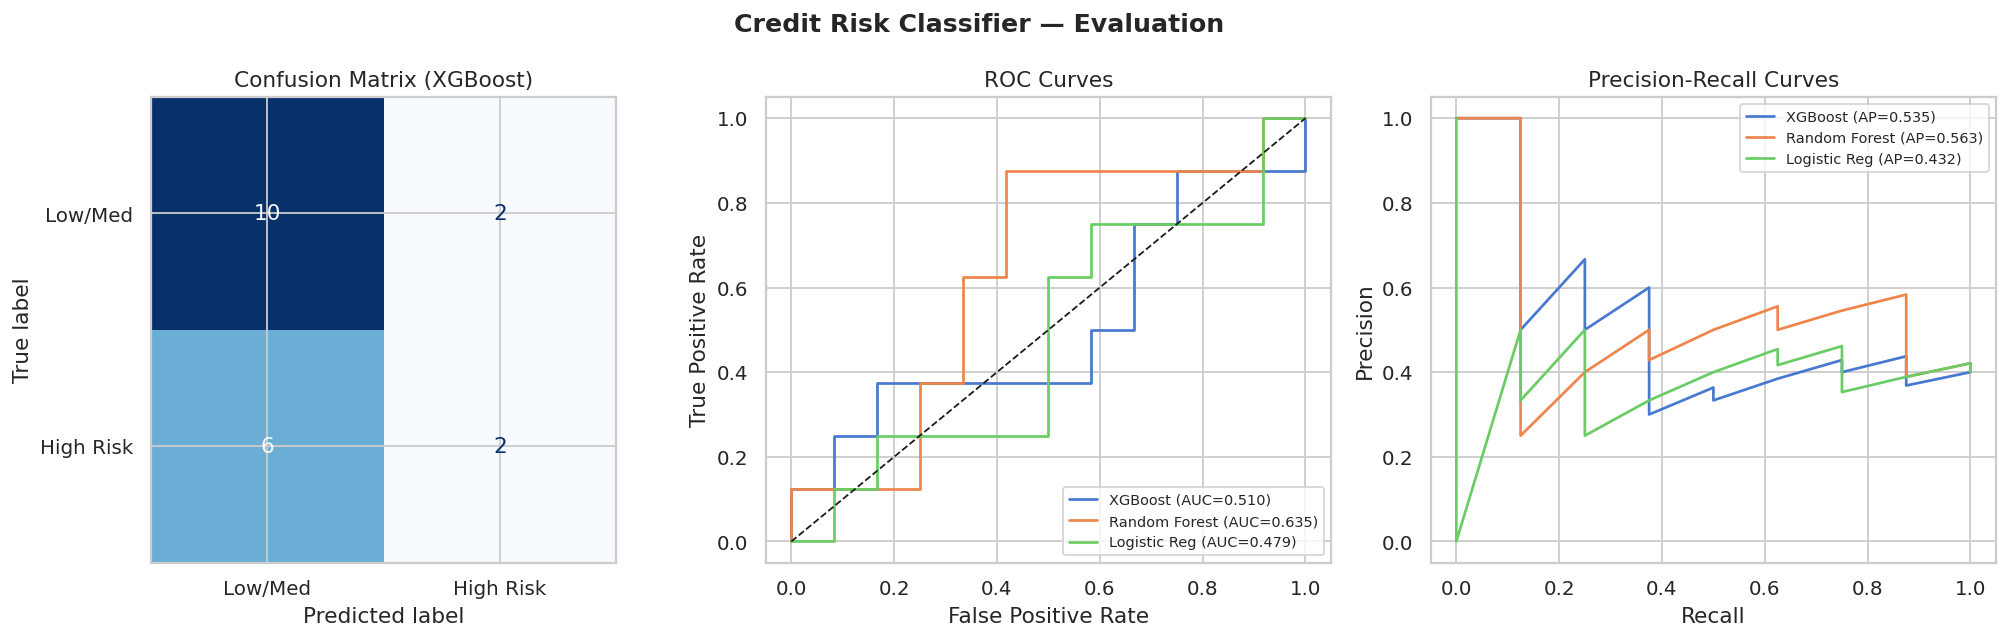

In [18]:
print("XGBoost — Classification Report (High-Risk Loans)")
print("=" * 55)
print(classification_report(y_test_c, clf_results["XGBoost"]["preds"],
                             target_names=["Low/Med Risk","High Risk"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Credit Risk Classifier — Evaluation", fontsize=14, fontweight="bold")

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, clf_results["XGBoost"]["preds"]),
    display_labels=["Low/Med","High Risk"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (XGBoost)")

# ROC curves — all models
for name, res in clf_results.items():
    fpr, tpr, _ = roc_curve(y_test_c, res["probs"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves")
axes[1].legend(fontsize=8)

# Precision-Recall
for name, res in clf_results.items():
    prec, rec, _ = precision_recall_curve(y_test_c, res["probs"])
    axes[2].plot(rec, prec, label=f"{name} (AP={res['AP']:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curves")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("06_credit_risk_classifier.png", bbox_inches="tight")
plt.show()

---
## 6. SHAP Explainability — Credit Risk

SHAP reveals which factors are driving each loan's risk score.
This is the explanation a lending officer gets when asked: *why was this loan flagged?*

In [19]:
explainer_cr = shap.TreeExplainer(xgb_clf)
shap_vals_cr = explainer_cr.shap_values(X_clf)

shap_imp_cr = pd.Series(
    np.abs(shap_vals_cr).mean(axis=0), index=CLF_FEATURES
).sort_values(ascending=False)

print("Top SHAP drivers — Credit Risk (High-Risk Classification):")
print(shap_imp_cr.round(4).to_string())

Top SHAP drivers — Credit Risk (High-Risk Classification):
Interest_Rate            0.5872
Annual_Income            0.5113
Loan_to_Income           0.4877
Debt_to_Income           0.4395
Credit_History_Length    0.3781
Debt_Service             0.3563
Loan_Amount              0.2140
Loan_Term_Months         0.1937
Customer_Enc             0.0908
Past_Default             0.0359


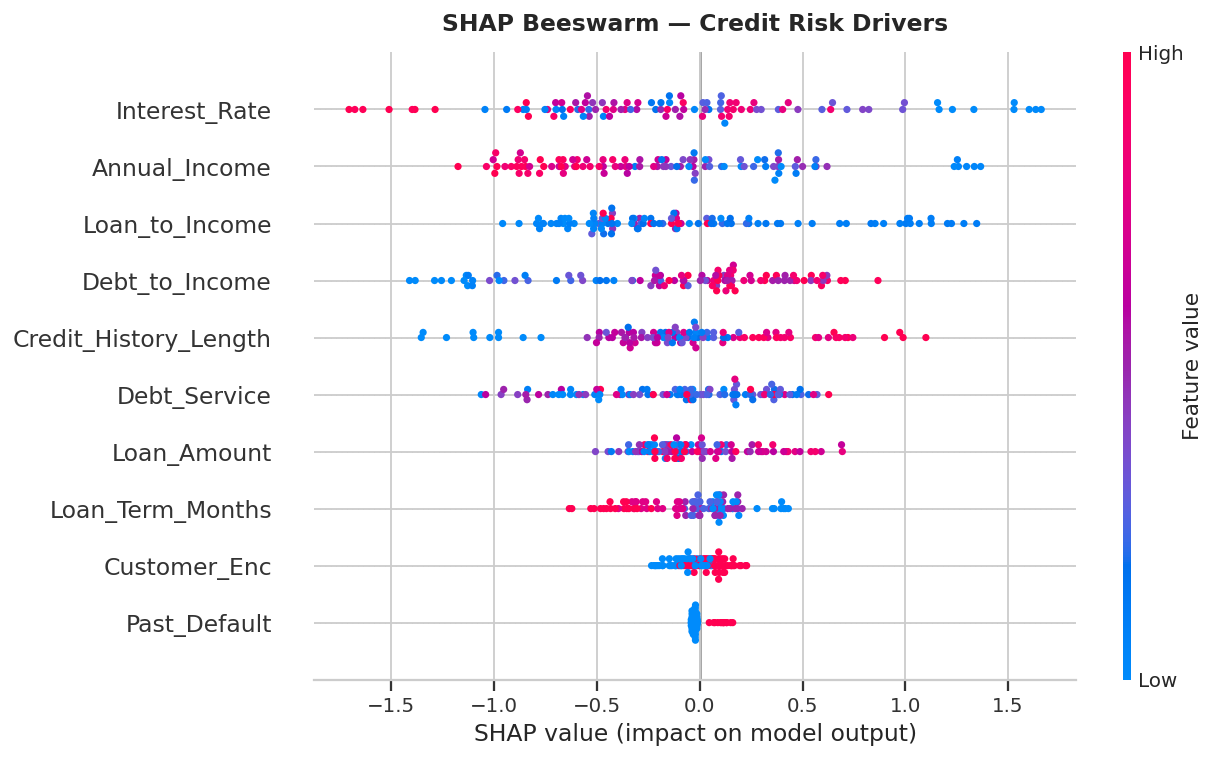

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_cr, X_clf, feature_names=CLF_FEATURES,
                  show=False, plot_size=(10, 6))
plt.title("SHAP Beeswarm — Credit Risk Drivers", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("07_shap_credit_beeswarm.png", bbox_inches="tight", dpi=130)
plt.show()

Explaining Loan #23 — highest risk score
Customer Type : Retail
PD            : 0.230
P(High Risk)  : 98.4%


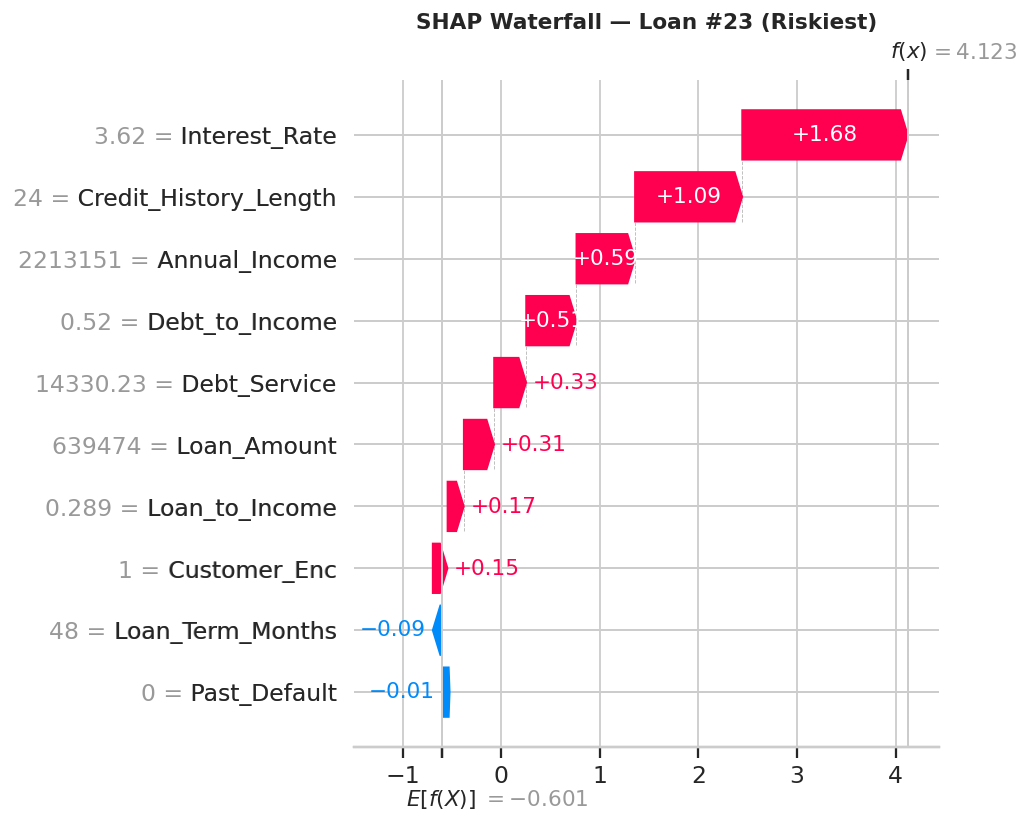

In [21]:
# Waterfall for the highest-risk loan
riskiest_idx = xgb_clf.predict_proba(X_clf)[:,1].argmax()
print(f"Explaining Loan #{loans.iloc[riskiest_idx]['Loan_ID']} — highest risk score")
print(f"Customer Type : {loans.iloc[riskiest_idx]['Customer_Type']}")
print(f"PD            : {loans.iloc[riskiest_idx]['PD']:.3f}")
print(f"P(High Risk)  : {xgb_clf.predict_proba(X_clf)[riskiest_idx,1]:.1%}")

exp2 = shap.Explainer(xgb_clf, X_clf)
sv2  = exp2(X_clf)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(sv2[riskiest_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall — Loan #{loans.iloc[riskiest_idx]['Loan_ID']} (Riskiest)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("08_shap_credit_waterfall.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 7. Risk-Scored Loan Portfolio

Attach predicted PD, high-risk probability, and a lending recommendation to every loan.

In [22]:
loans["Pred_PD"]        = xgb_reg.predict(loans[REG_FEATURES]).clip(0, 1).round(4)
loans["P_HighRisk"]     = xgb_clf.predict_proba(loans[CLF_FEATURES])[:, 1].round(4)
loans["Risk_Score"]     = (loans["P_HighRisk"] * 100).round(1)   # 0–100 scale

def recommend(row):
    if row["P_HighRisk"] >= 0.60:
        return "DECLINE"
    elif row["P_HighRisk"] >= 0.30:
        return "MONITOR"
    else:
        return "APPROVE"

loans["Recommendation"] = loans.apply(recommend, axis=1)

rec_cols = ["Loan_ID","Customer_Type","Loan_Amount","Annual_Income",
             "Debt_to_Income","PD","Pred_PD","Risk_Score","Recommendation"]

print("=== RISK-SCORED LOAN PORTFOLIO ===")
print(loans[rec_cols].sort_values("Risk_Score", ascending=False).to_string(index=False))

=== RISK-SCORED LOAN PORTFOLIO ===
 Loan_ID Customer_Type  Loan_Amount  Annual_Income  Debt_to_Income   PD  Pred_PD  Risk_Score Recommendation
      23        Retail       639474        2213151            0.52 0.23   0.2600   98.400002        DECLINE
      90        Retail       533138        2645075            0.19 0.26   0.2584   96.800003        DECLINE
      40        Retail       276776        1256607            0.57 0.29   0.2178   96.500000        DECLINE
      44        Retail       409384        1642818            0.66 0.26   0.2589   96.300003        DECLINE
      62        Retail       372920        2449862            0.89 0.21   0.2126   95.500000        DECLINE
      95     Corporate       805543        2938873            0.78 0.24   0.2411   94.900002        DECLINE
      33     Corporate       257736         705510            0.81 0.21   0.2120   94.800003        DECLINE
      71        Retail       813692        4262406            0.32 0.25   0.2062   94.500000        D

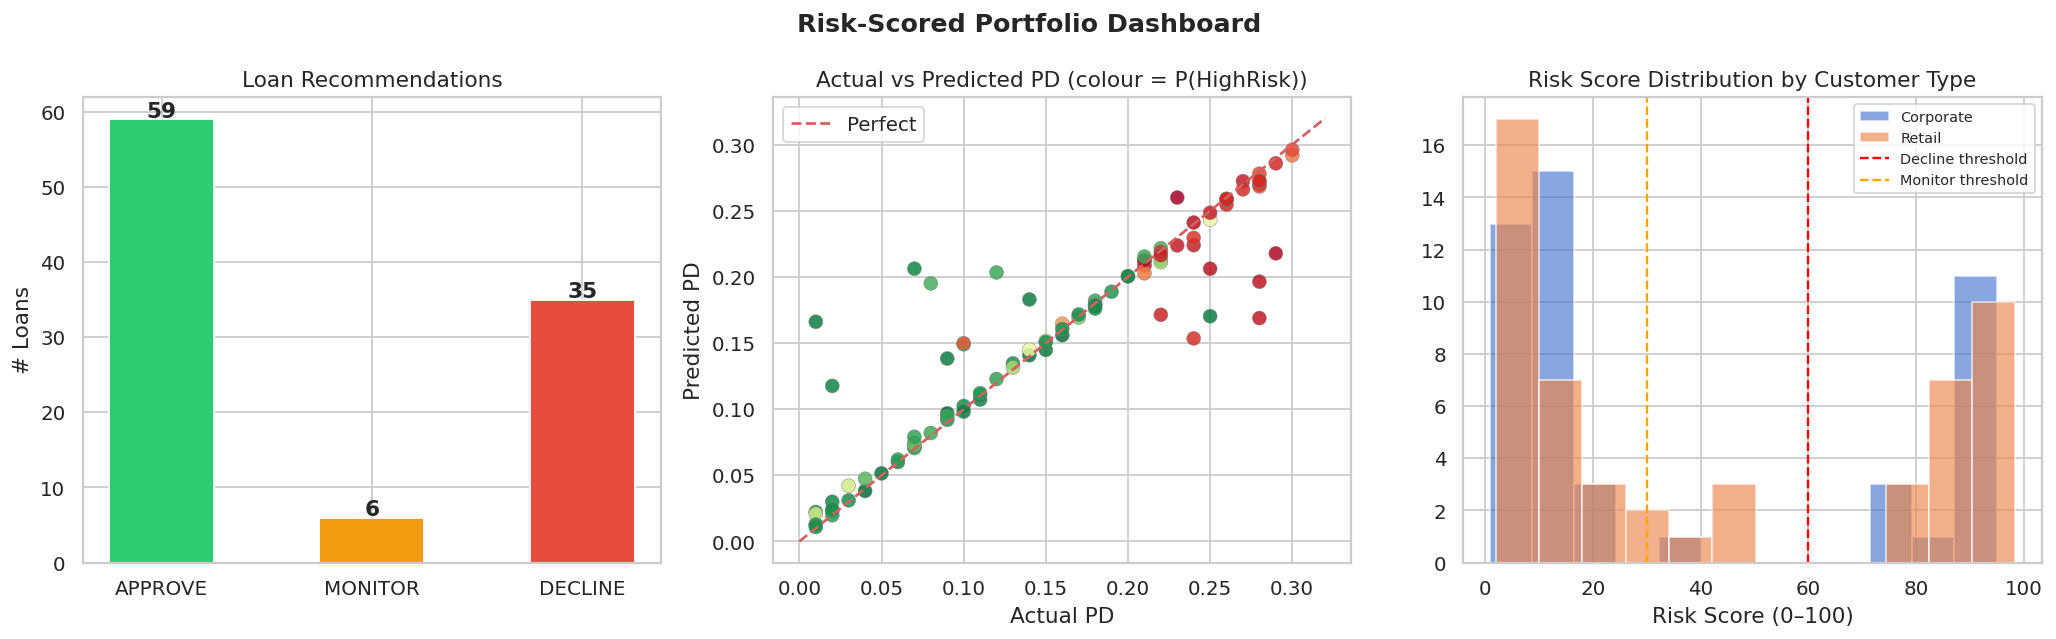

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Risk-Scored Portfolio Dashboard", fontsize=14, fontweight="bold")

# Recommendation split
rec_counts = loans["Recommendation"].value_counts().reindex(["APPROVE","MONITOR","DECLINE"])
colors_rec = ["#2ecc71","#f39c12","#e74c3c"]
axes[0].bar(rec_counts.index, rec_counts.values, color=colors_rec, edgecolor="white", width=0.5)
axes[0].set_title("Loan Recommendations")
axes[0].set_ylabel("# Loans")
for i, (cat, val) in enumerate(rec_counts.items()):
    axes[0].text(i, val+0.3, str(val), ha="center", fontweight="bold")

# Predicted PD vs Actual PD
axes[1].scatter(loans["PD"], loans["Pred_PD"], c=loans["P_HighRisk"],
                cmap="RdYlGn_r", s=60, edgecolors="grey", linewidth=0.3, alpha=0.85)
axes[1].plot([0,0.32],[0,0.32], "r--", lw=1.5, label="Perfect")
axes[1].set_xlabel("Actual PD")
axes[1].set_ylabel("Predicted PD")
axes[1].set_title("Actual vs Predicted PD (colour = P(HighRisk))")
axes[1].legend()

# Risk score by customer type
for ct, grp in loans.groupby("Customer_Type"):
    axes[2].hist(grp["Risk_Score"], bins=12, alpha=0.65, label=ct, edgecolor="white")
axes[2].axvline(60, color="red", linestyle="--", lw=1.3, label="Decline threshold")
axes[2].axvline(30, color="orange", linestyle="--", lw=1.3, label="Monitor threshold")
axes[2].set_title("Risk Score Distribution by Customer Type")
axes[2].set_xlabel("Risk Score (0–100)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("09_portfolio_dashboard.png", bbox_inches="tight")
plt.show()

---
## 8. Fraud Detection — Part A: Supervised Classification

**Challenge:** Only 4.5% of transactions are fraudulent — a severe class imbalance.
We use **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the training data,
then train XGBoost and Random Forest classifiers.

In [24]:
FRAUD_FEATURES = ["Amount","TxnType_Enc","Hour","DayOfWeek","IsWeekend","IsNight",
                   "Amount_Zscore","Txn_Count","Avg_Amount","Max_Amount"]

X_fraud = txns[FRAUD_FEATURES]
y_fraud = txns["Fraud_Flag"]

print(f"Class balance before SMOTE: {y_fraud.value_counts().to_dict()}")
print(f"Fraud rate: {y_fraud.mean():.1%}")

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=42)

# SMOTE on training set only
sm = SMOTE(random_state=42, k_neighbors=min(3, y_train_f.sum()-1))
X_train_sm, y_train_sm = sm.fit_resample(X_train_f, y_train_f)

print(f"Class balance after  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Train size after SMOTE: {len(X_train_sm)}")

Class balance before SMOTE: {0: 191, 1: 9}
Fraud rate: 4.5%
Class balance after  SMOTE: {0: 153, 1: 153}
Train size after SMOTE: 306


In [25]:
xgb_fr = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.04,
                             subsample=0.8, colsample_bytree=0.8,
                             eval_metric="logloss", random_state=42, verbosity=0)
rf_fr  = RandomForestClassifier(n_estimators=300, max_depth=6,
                                 class_weight="balanced", random_state=42)

fraud_results = {}
for name, model in [("XGBoost", xgb_fr), ("Random Forest", rf_fr)]:
    model.fit(X_train_sm, y_train_sm)
    preds  = model.predict(X_test_f)
    probs  = model.predict_proba(X_test_f)[:, 1]
    auc    = roc_auc_score(y_test_f, probs)
    ap     = average_precision_score(y_test_f, probs)
    fraud_results[name] = {"model": model, "preds": preds, "probs": probs,
                            "AUC": auc, "AP": ap}
    print(f"{name:15s} | AUC: {auc:.4f} | Avg Precision (PR-AUC): {ap:.4f}")
    print(classification_report(y_test_f, preds, target_names=["Legit","Fraud"]))
    print()

XGBoost         | AUC: 0.4474 | Avg Precision (PR-AUC): 0.0977
              precision    recall  f1-score   support

       Legit       0.94      0.84      0.89        38
       Fraud       0.00      0.00      0.00         2

    accuracy                           0.80        40
   macro avg       0.47      0.42      0.44        40
weighted avg       0.89      0.80      0.84        40


Random Forest   | AUC: 0.4342 | Avg Precision (PR-AUC): 0.0688
              precision    recall  f1-score   support

       Legit       0.96      0.68      0.80        38
       Fraud       0.08      0.50      0.13         2

    accuracy                           0.68        40
   macro avg       0.52      0.59      0.47        40
weighted avg       0.92      0.68      0.77        40




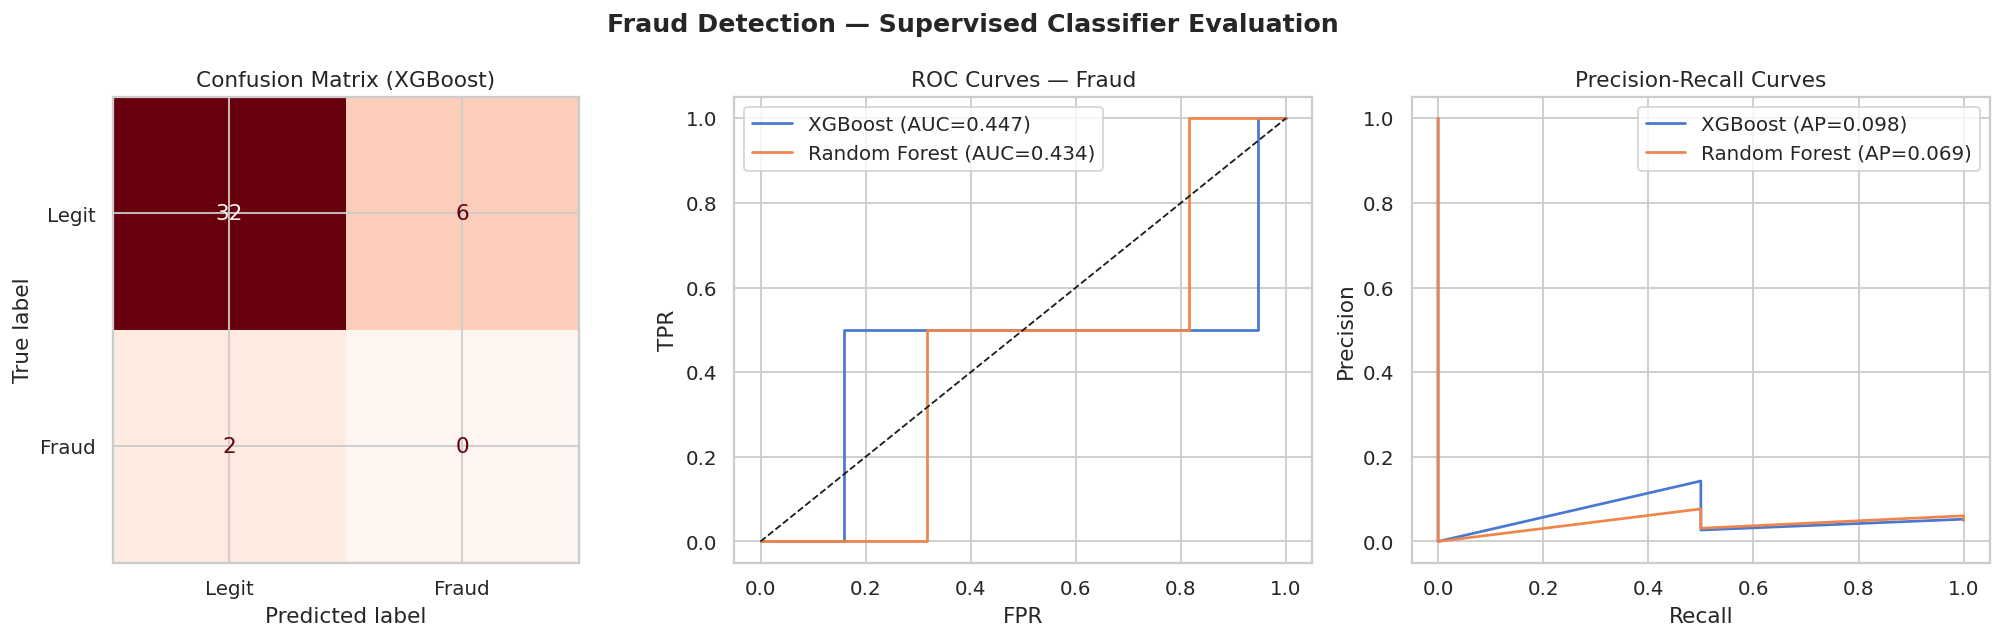

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fraud Detection — Supervised Classifier Evaluation", fontsize=14, fontweight="bold")

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test_f, fraud_results["XGBoost"]["preds"]),
    display_labels=["Legit","Fraud"]).plot(ax=axes[0], colorbar=False, cmap="Reds")
axes[0].set_title("Confusion Matrix (XGBoost)")

# ROC
for name, res in fraud_results.items():
    fpr, tpr, _ = roc_curve(y_test_f, res["probs"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_title("ROC Curves — Fraud")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend()

# PR curve (better for imbalanced)
for name, res in fraud_results.items():
    prec, rec, _ = precision_recall_curve(y_test_f, res["probs"])
    axes[2].plot(rec, prec, label=f"{name} (AP={res['AP']:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curves")
axes[2].legend()

plt.tight_layout()
plt.savefig("10_fraud_supervised.png", bbox_inches="tight")
plt.show()

---
## 9. Fraud Detection — Part B: Unsupervised Anomaly Detection

In real fraud systems, labels are often unavailable or delayed.
We apply **Isolation Forest** and **Local Outlier Factor** to detect anomalies
without using the Fraud_Flag labels during training.

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(txns[FRAUD_FEATURES])

# Isolation Forest (state-of-the-art anomaly detection for tabular data)
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
iso.fit(X_scaled)
txns["IF_Score"]  = -iso.score_samples(X_scaled)   # higher = more anomalous
txns["IF_Flag"]   = (iso.predict(X_scaled) == -1).astype(int)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
txns["LOF_Flag"]  = (lof.fit_predict(X_scaled) == -1).astype(int)
txns["LOF_Score"] = -lof.negative_outlier_factor_   # higher = more anomalous

print("Isolation Forest — overlap with actual fraud labels:")
print(pd.crosstab(txns["Fraud_Flag"], txns["IF_Flag"],
                  rownames=["Actual Fraud"], colnames=["IF Alert"]))
print()
iso_auc = roc_auc_score(txns["Fraud_Flag"], txns["IF_Score"])
lof_auc = roc_auc_score(txns["Fraud_Flag"], txns["LOF_Score"])
print(f"Isolation Forest AUC (unsupervised): {iso_auc:.4f}")
print(f"Local Outlier Factor AUC           : {lof_auc:.4f}")

Isolation Forest — overlap with actual fraud labels:
IF Alert        0   1
Actual Fraud         
0             181  10
1               9   0

Isolation Forest AUC (unsupervised): 0.6114
Local Outlier Factor AUC           : 0.5654


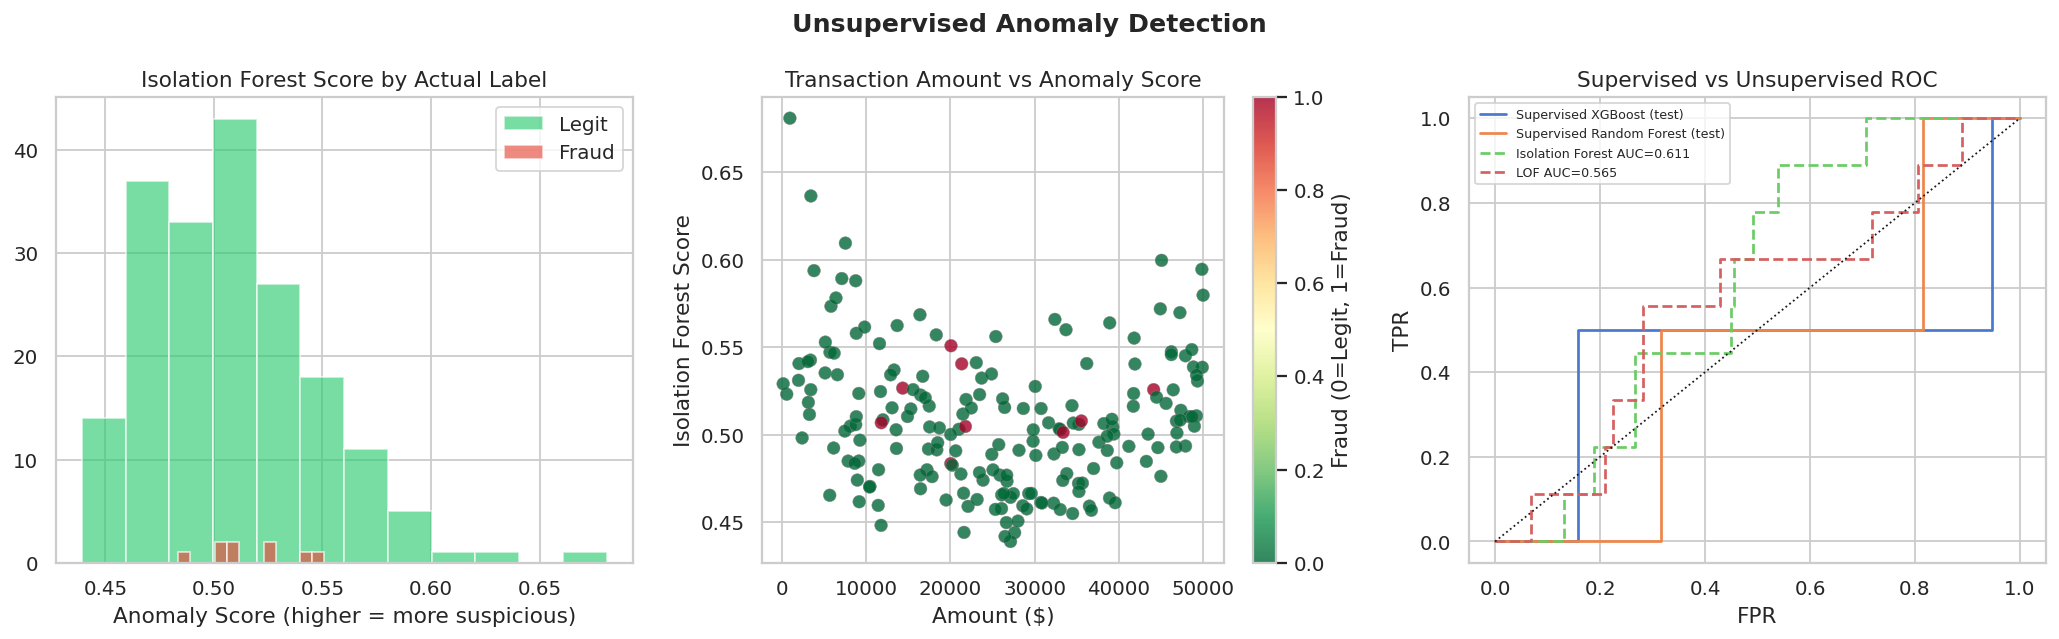

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Unsupervised Anomaly Detection", fontsize=14, fontweight="bold")

# IF score distribution
for f, grp in txns.groupby("Fraud_Flag"):
    axes[0].hist(grp["IF_Score"], bins=12, alpha=0.65,
                 label=["Legit","Fraud"][f],
                 color=["#2ecc71","#e74c3c"][f], edgecolor="white")
axes[0].set_title("Isolation Forest Score by Actual Label")
axes[0].set_xlabel("Anomaly Score (higher = more suspicious)")
axes[0].legend()

# Amount vs IF Score scatter
sc = axes[1].scatter(txns["Amount"], txns["IF_Score"],
                     c=txns["Fraud_Flag"], cmap="RdYlGn_r",
                     s=50, edgecolors="grey", linewidth=0.3, alpha=0.8)
axes[1].set_title("Transaction Amount vs Anomaly Score")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Isolation Forest Score")
fig.colorbar(sc, ax=axes[1], label="Fraud (0=Legit, 1=Fraud)")

# ROC comparison: supervised vs unsupervised
for name, res in fraud_results.items():
    fpr, tpr, _ = roc_curve(y_test_f, res["probs"])
    axes[2].plot(fpr, tpr, label=f"Supervised {name} (test)")

fpr_if, tpr_if, _ = roc_curve(txns["Fraud_Flag"], txns["IF_Score"])
fpr_lf, tpr_lf, _ = roc_curve(txns["Fraud_Flag"], txns["LOF_Score"])
axes[2].plot(fpr_if, tpr_if, "--", label=f"Isolation Forest AUC={iso_auc:.3f}")
axes[2].plot(fpr_lf, tpr_lf, "--", label=f"LOF AUC={lof_auc:.3f}")
axes[2].plot([0,1],[0,1],"k:", lw=1)
axes[2].set_title("Supervised vs Unsupervised ROC")
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("11_fraud_unsupervised.png", bbox_inches="tight")
plt.show()

---
## 10. SHAP Explainability — Fraud Detection

Which features drive the fraud prediction?
A fraud analyst seeing an alert needs to know *why* the transaction was flagged.

In [29]:
explainer_fr = shap.TreeExplainer(xgb_fr)
shap_vals_fr = explainer_fr.shap_values(X_fraud)

shap_imp_fr = pd.Series(
    np.abs(shap_vals_fr).mean(axis=0), index=FRAUD_FEATURES
).sort_values(ascending=False)

print("Top SHAP drivers — Fraud Detection:")
print(shap_imp_fr.round(4).to_string())

Top SHAP drivers — Fraud Detection:
Amount           1.2642
Avg_Amount       0.8514
DayOfWeek        0.8033
Amount_Zscore    0.8019
Txn_Count        0.5540
Max_Amount       0.5515
IsWeekend        0.1680
TxnType_Enc      0.1558
IsNight          0.0000
Hour             0.0000


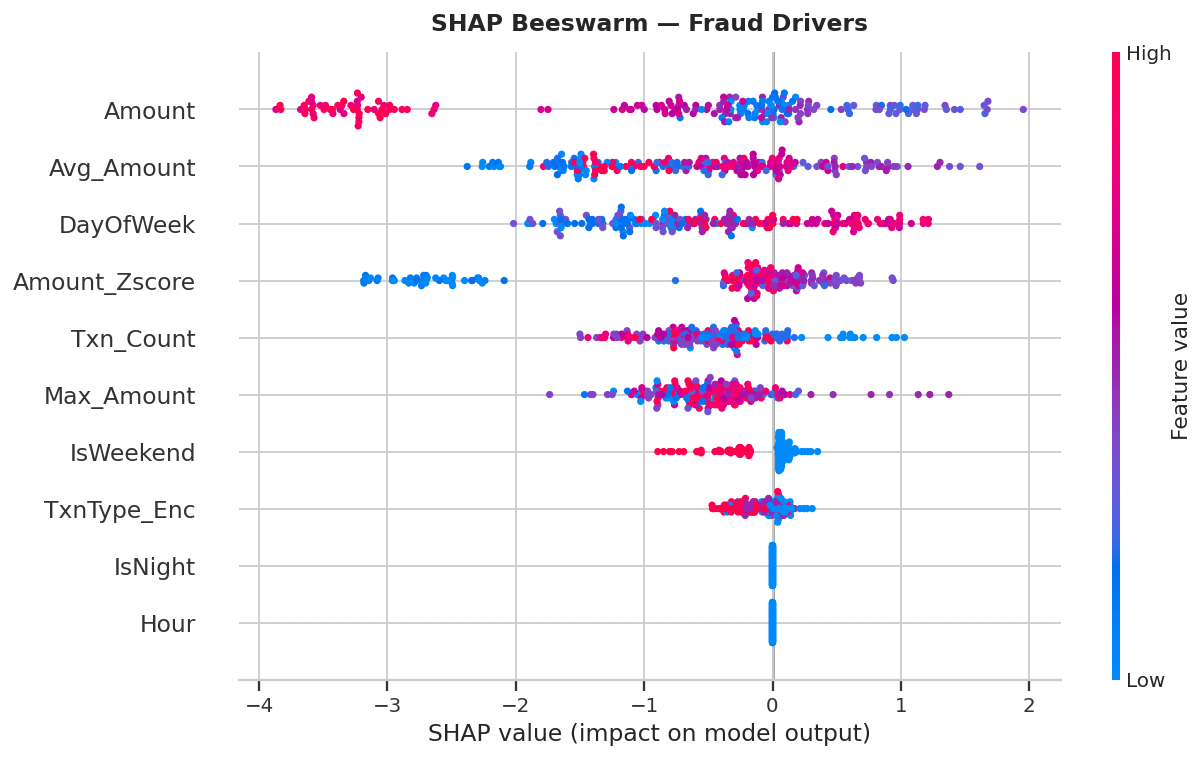

In [30]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_fr, X_fraud, feature_names=FRAUD_FEATURES,
                  show=False, plot_size=(10, 6))
plt.title("SHAP Beeswarm — Fraud Drivers", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("12_shap_fraud_beeswarm.png", bbox_inches="tight", dpi=130)
plt.show()

Explaining Transaction #88
Type       : Transfer
Amount     : $20,044
Actual Flag: 1
P(Fraud)   : 97.8%


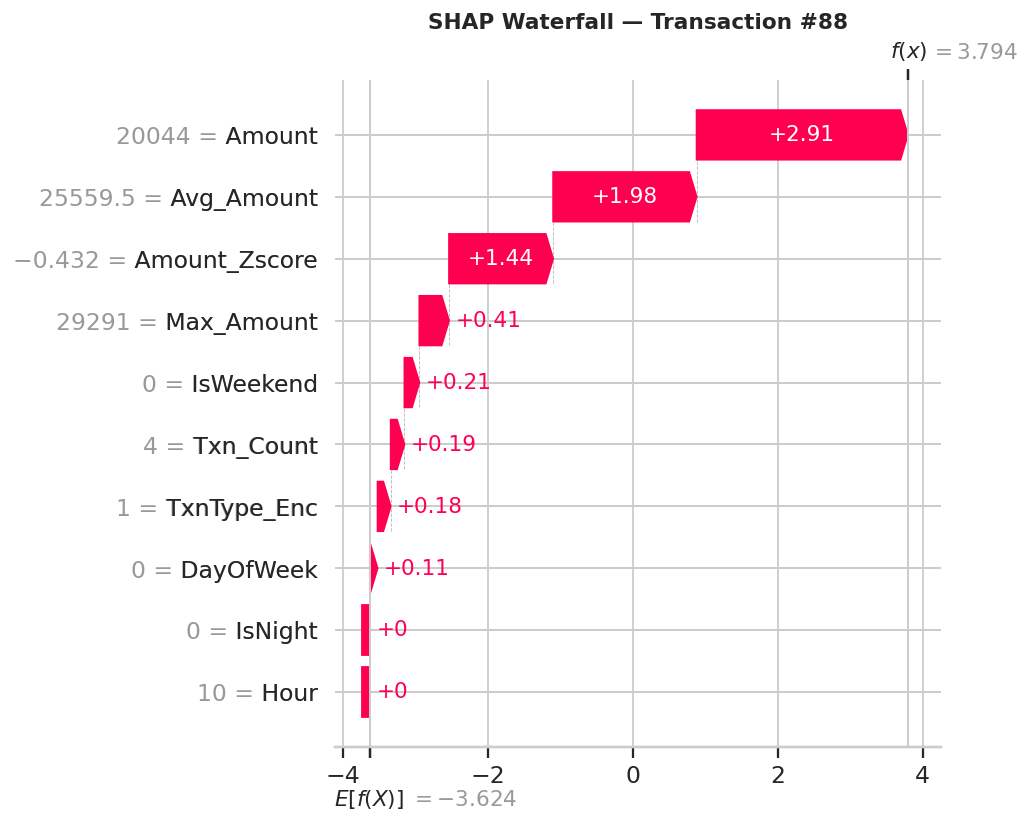

In [31]:
# Waterfall for the highest-risk transaction
top_fraud_idx = xgb_fr.predict_proba(X_fraud)[:,1].argmax()
print(f"Explaining Transaction #{txns.iloc[top_fraud_idx]['Transaction_ID']}")
print(f"Type       : {txns.iloc[top_fraud_idx]['Transaction_Type']}")
print(f"Amount     : ${txns.iloc[top_fraud_idx]['Amount']:,.0f}")
print(f"Actual Flag: {txns.iloc[top_fraud_idx]['Fraud_Flag']}")
print(f"P(Fraud)   : {xgb_fr.predict_proba(X_fraud)[top_fraud_idx,1]:.1%}")

exp_fr2 = shap.Explainer(xgb_fr, X_fraud)
sv_fr2  = exp_fr2(X_fraud)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(sv_fr2[top_fraud_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall — Transaction #{txns.iloc[top_fraud_idx]['Transaction_ID']}",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("13_shap_fraud_waterfall.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 11. Fraud Alert Dashboard

Assign a fraud alert level to every transaction and build the operational alert table.

In [32]:
txns["P_Fraud"]      = xgb_fr.predict_proba(X_fraud)[:,1].round(4)
txns["Fraud_Score"]  = (txns["P_Fraud"] * 100).round(1)

def fraud_alert(p):
    if p >= 0.60:  return "🔴 HIGH"
    elif p >= 0.30: return "🟡 MEDIUM"
    else:           return "🟢 LOW"

txns["Alert_Level"] = txns["P_Fraud"].apply(fraud_alert)

alert_cols = ["Transaction_ID","Customer_ID","Amount","Transaction_Type",
               "Timestamp","Fraud_Flag","P_Fraud","Fraud_Score","Alert_Level"]

print("=== FRAUD ALERT DASHBOARD ===")
print(txns[txns["P_Fraud"] >= 0.30][alert_cols].sort_values(
    "Fraud_Score", ascending=False).to_string(index=False))

=== FRAUD ALERT DASHBOARD ===
 Transaction_ID  Customer_ID  Amount Transaction_Type                  Timestamp  Fraud_Flag  P_Fraud  Fraud_Score Alert_Level
             88           56   20044         Transfer 2025-02-24 10:47:51.201549           1   0.9780    97.800003      🔴 HIGH
            179           66   33370       Withdrawal 2025-09-05 10:47:51.202366           1   0.9571    95.699997      🔴 HIGH
             53           63   17532       Withdrawal 2025-09-05 10:47:51.201204           0   0.9268    92.699997      🔴 HIGH
             40           88   11795       Withdrawal 2025-04-22 10:47:51.201088           1   0.9043    90.400002      🔴 HIGH
             44           98   14338          Payment 2025-09-19 10:47:51.201124           1   0.8944    89.400002      🔴 HIGH
            150           89   35538          Payment 2025-11-15 10:47:51.202109           1   0.8695    87.000000      🔴 HIGH
            128           58   17823         Transfer 2025-05-30 10:47:51.201904 

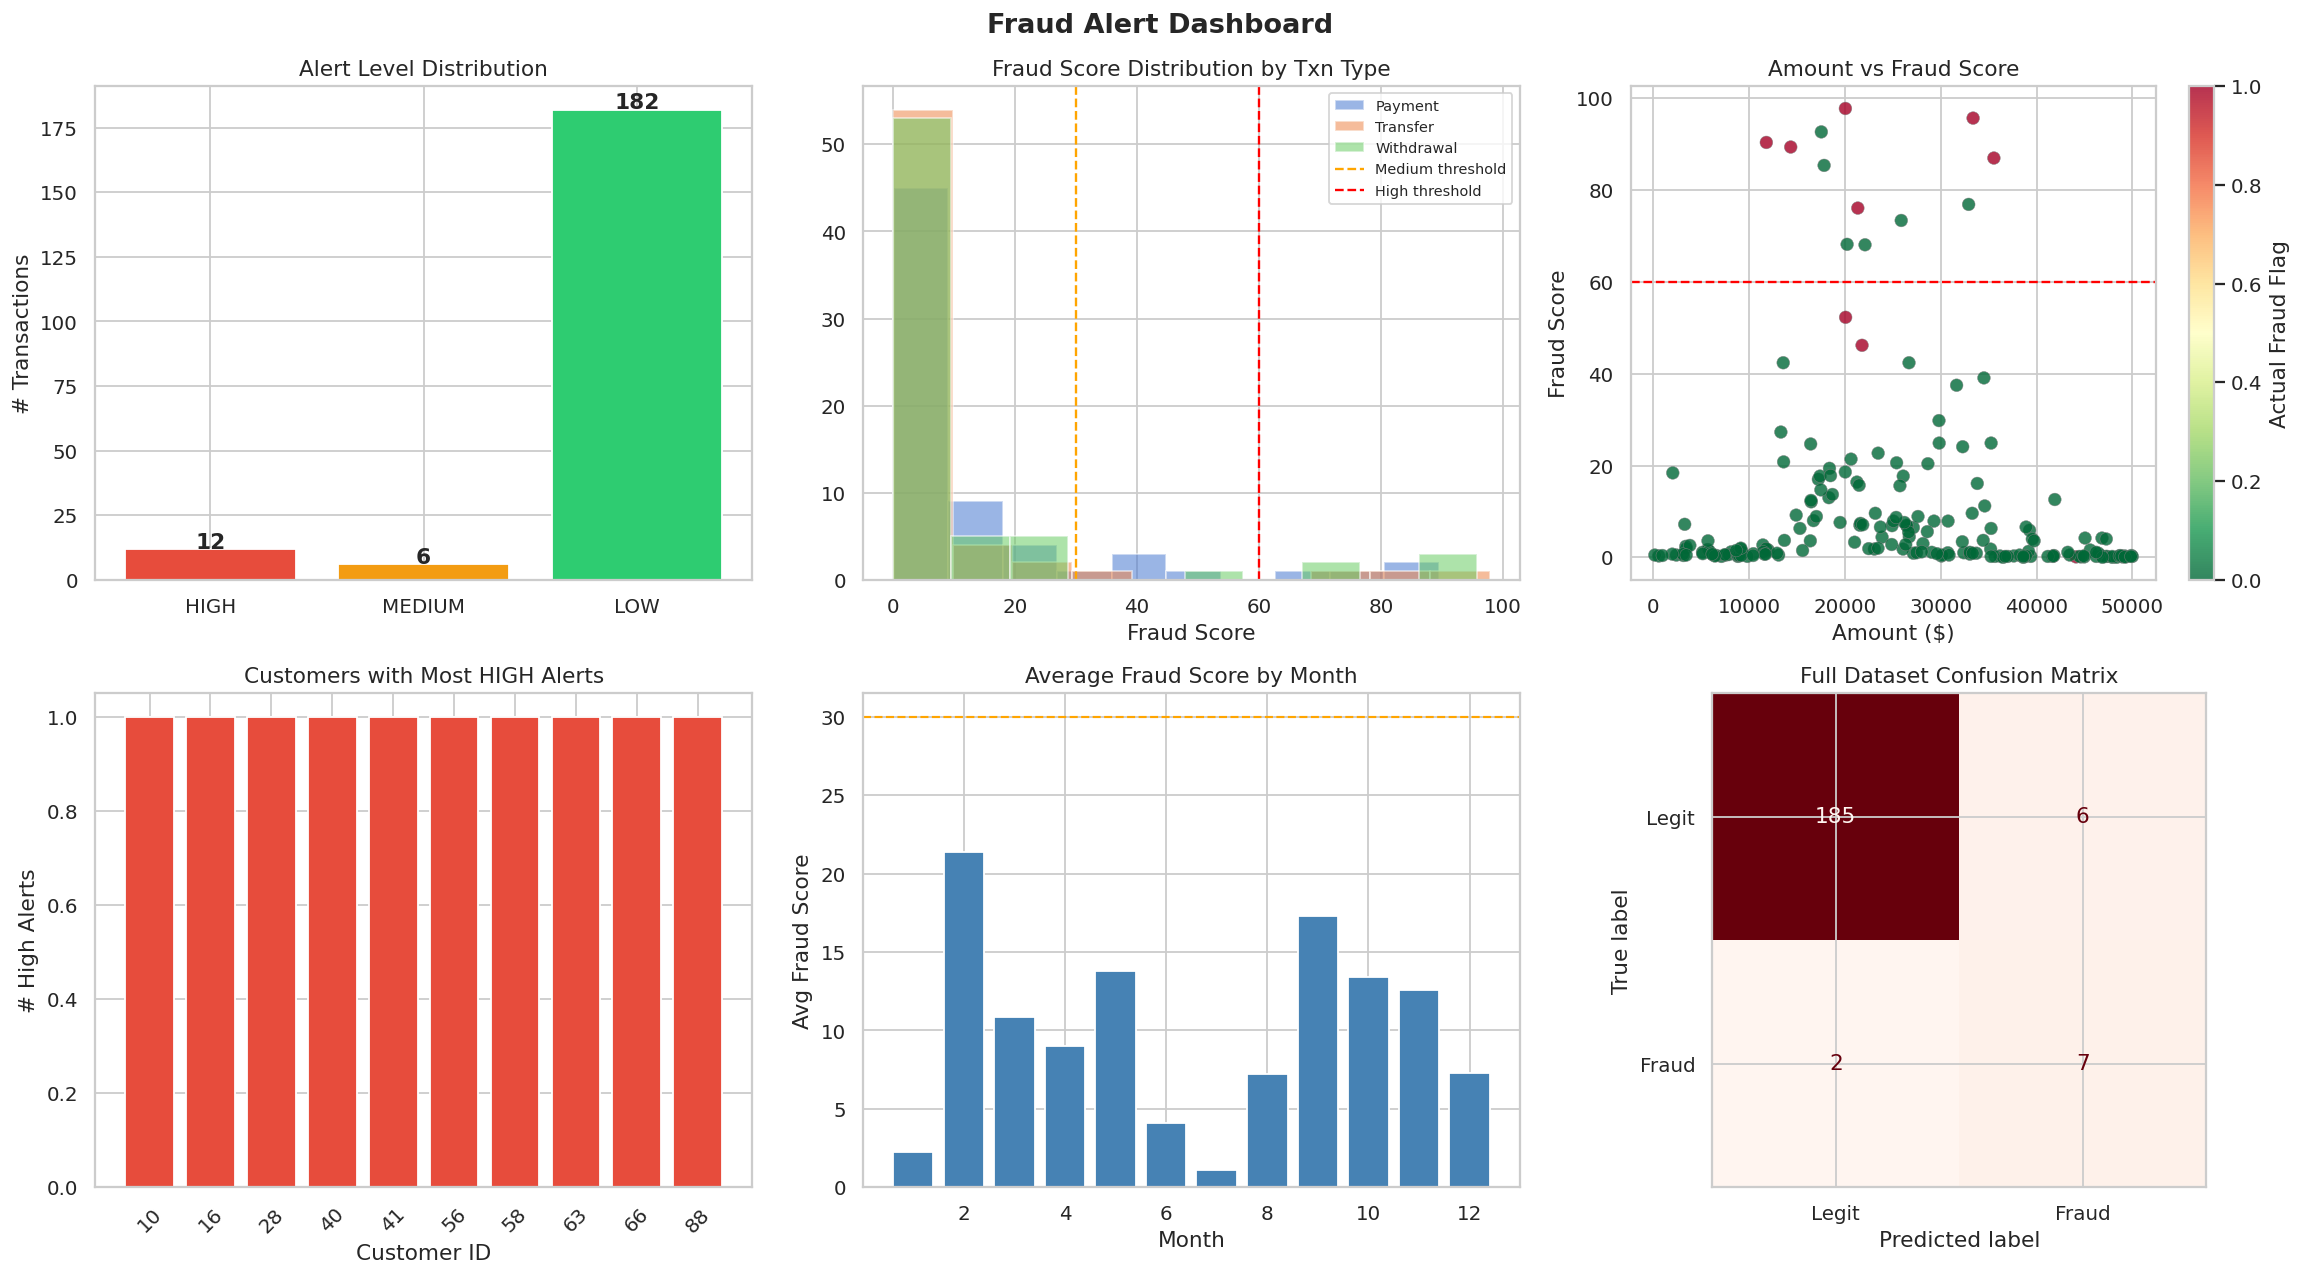

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Fraud Alert Dashboard", fontsize=15, fontweight="bold")

# Alert level distribution
alert_counts = txns["Alert_Level"].str.extract(r"(HIGH|MEDIUM|LOW)")[0].value_counts()
alert_counts = alert_counts.reindex(["HIGH","MEDIUM","LOW"])
axes[0,0].bar(alert_counts.index, alert_counts.values,
               color=["#e74c3c","#f39c12","#2ecc71"], edgecolor="white")
axes[0,0].set_title("Alert Level Distribution")
axes[0,0].set_ylabel("# Transactions")
for i, v in enumerate(alert_counts.values):
    axes[0,0].text(i, v+0.3, str(v), ha="center", fontweight="bold")

# Fraud score by transaction type
for t, grp in txns.groupby("Transaction_Type"):
    axes[0,1].hist(grp["Fraud_Score"], bins=10, alpha=0.55, label=t, edgecolor="white")
axes[0,1].axvline(30, color="orange", linestyle="--", lw=1.3, label="Medium threshold")
axes[0,1].axvline(60, color="red",    linestyle="--", lw=1.3, label="High threshold")
axes[0,1].set_title("Fraud Score Distribution by Txn Type")
axes[0,1].set_xlabel("Fraud Score")
axes[0,1].legend(fontsize=8)

# Amount vs Fraud Score
sc = axes[0,2].scatter(txns["Amount"], txns["Fraud_Score"],
                        c=txns["Fraud_Flag"], cmap="RdYlGn_r",
                        s=50, edgecolors="grey", linewidth=0.3, alpha=0.8)
axes[0,2].axhline(60, color="red", linestyle="--", lw=1.3)
axes[0,2].set_title("Amount vs Fraud Score")
axes[0,2].set_xlabel("Amount ($)")
axes[0,2].set_ylabel("Fraud Score")
fig.colorbar(sc, ax=axes[0,2], label="Actual Fraud Flag")

# High-alert customers
top_cust = (txns[txns["P_Fraud"]>=0.60]
            .groupby("Customer_ID")["Transaction_ID"].count()
            .sort_values(ascending=False).head(10))
axes[1,0].bar(top_cust.index.astype(str), top_cust.values, color="#e74c3c", edgecolor="white")
axes[1,0].set_title("Customers with Most HIGH Alerts")
axes[1,0].set_xlabel("Customer ID")
axes[1,0].set_ylabel("# High Alerts")
axes[1,0].tick_params(axis="x", rotation=45)

# Monthly fraud score heat
monthly_score = txns.groupby("Month")["Fraud_Score"].mean()
axes[1,1].bar(monthly_score.index, monthly_score.values, color="steelblue", edgecolor="white")
axes[1,1].set_title("Average Fraud Score by Month")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Avg Fraud Score")
axes[1,1].axhline(30, color="orange", linestyle="--", lw=1.2)

# Confusion matrix (all txns)
y_all_pred = xgb_fr.predict(X_fraud)
ConfusionMatrixDisplay(
    confusion_matrix(txns["Fraud_Flag"], y_all_pred),
    display_labels=["Legit","Fraud"]).plot(ax=axes[1,2], colorbar=False, cmap="Reds")
axes[1,2].set_title("Full Dataset Confusion Matrix")

plt.tight_layout()
plt.savefig("14_fraud_dashboard.png", bbox_inches="tight")
plt.show()

---
## 12. Executive Summary for Lending Officers

In [34]:
approve  = (loans["Recommendation"] == "APPROVE").sum()
monitor  = (loans["Recommendation"] == "MONITOR").sum()
decline  = (loans["Recommendation"] == "DECLINE").sum()

high_alerts  = (txns["Alert_Level"].str.contains("HIGH")).sum()
med_alerts   = (txns["Alert_Level"].str.contains("MEDIUM")).sum()
confirmed_fr = txns["Fraud_Flag"].sum()

total_loan_value  = loans["Loan_Amount"].sum()
decline_value     = loans[loans["Recommendation"]=="DECLINE"]["Loan_Amount"].sum()
monitor_value     = loans[loans["Recommendation"]=="MONITOR"]["Loan_Amount"].sum()

print("=" * 65)
print("  AURORA BANKING MODULE — EXECUTIVE SUMMARY")
print("=" * 65)
print()
print("  CREDIT RISK — LOAN PORTFOLIO")
print("-" * 65)
print(f"  Total loans assessed         : {len(loans)}")
print(f"  APPROVE                      : {approve}  ({approve/len(loans):.0%})")
print(f"  MONITOR (requires review)    : {monitor}  ({monitor/len(loans):.0%})")
print(f"  DECLINE                      : {decline}  ({decline/len(loans):.0%})")
print()
print(f"  Total loan value assessed    : ${total_loan_value:>12,.0f}")
print(f"  Value flagged for DECLINE    : ${decline_value:>12,.0f}")
print(f"  Value flagged for MONITOR    : ${monitor_value:>12,.0f}")
print()
print("  TOP 5 HIGHEST-RISK LOANS:")
top5_risk = loans.nlargest(5, "Risk_Score")[
    ["Loan_ID","Customer_Type","Loan_Amount","PD","Risk_Score","Recommendation"]]
for _, r in top5_risk.iterrows():
    print(f"  Loan {int(r.Loan_ID):>3} | {r.Customer_Type:<10} | "
          f"${r.Loan_Amount/1e6:.2f}M | PD={r.PD:.2f} | "
          f"Score={r.Risk_Score:.0f} | {r.Recommendation}")
print()
print("  FRAUD DETECTION — TRANSACTIONS")
print("-" * 65)
print(f"  Total transactions monitored : {len(txns)}")
print(f"  HIGH alerts (review now)     : {high_alerts}")
print(f"  MEDIUM alerts (watch)        : {med_alerts}")
print(f"  Confirmed fraud (labelled)   : {confirmed_fr}")
print()
print("  KEY RISK DRIVERS (SHAP — Credit Risk):")
for feat, val in shap_imp_cr.head(3).items():
    print(f"  - {feat:<30}  Mean |SHAP| = {val:.4f}")
print()
print("  KEY FRAUD DRIVERS (SHAP — Fraud):")
for feat, val in shap_imp_fr.head(3).items():
    print(f"  - {feat:<30}  Mean |SHAP| = {val:.4f}")
print()
print("  RECOMMENDATIONS:")
print("-" * 65)
print("  1. Immediately review all DECLINE loans before any disbursement.")
print("  2. MONITOR loans require quarterly covenant checks and income revalidation.")
print("  3. HIGH fraud alerts should be escalated to the fraud team within 24hrs.")
print("  4. Past_Default is the strongest credit risk signal — verify it at onboarding.")
print("  5. Re-score the portfolio monthly as market conditions evolve.")
print("=" * 65)

  AURORA BANKING MODULE — EXECUTIVE SUMMARY

  CREDIT RISK — LOAN PORTFOLIO
-----------------------------------------------------------------
  Total loans assessed         : 100
  APPROVE                      : 59  (59%)
  MONITOR (requires review)    : 6  (6%)
  DECLINE                      : 35  (35%)

  Total loan value assessed    : $  50,976,728
  Value flagged for DECLINE    : $  18,518,172
  Value flagged for MONITOR    : $   4,178,201

  TOP 5 HIGHEST-RISK LOANS:
  Loan  23 | Retail     | $0.64M | PD=0.23 | Score=98 | DECLINE
  Loan  90 | Retail     | $0.53M | PD=0.26 | Score=97 | DECLINE
  Loan  40 | Retail     | $0.28M | PD=0.29 | Score=96 | DECLINE
  Loan  44 | Retail     | $0.41M | PD=0.26 | Score=96 | DECLINE
  Loan  62 | Retail     | $0.37M | PD=0.21 | Score=96 | DECLINE

  FRAUD DETECTION — TRANSACTIONS
-----------------------------------------------------------------
  Total transactions monitored : 200
  HIGH alerts (review now)     : 12
  MEDIUM alerts (watch)       

In [35]:
# ── Export outputs ───────────────────────────────────────────────────────────
loans_out = loans[["Loan_ID","Customer_Type","Loan_Amount","Annual_Income",
                    "Debt_to_Income","PD","Pred_PD","Risk_Score","Recommendation"]]
loans_out.to_csv("aurora_loan_risk_scores.csv", index=False)

fraud_out = txns[["Transaction_ID","Customer_ID","Amount","Transaction_Type",
                   "Timestamp","Fraud_Flag","P_Fraud","Fraud_Score","Alert_Level"]]
fraud_out.to_csv("aurora_fraud_alerts.csv", index=False)

print("Exported: aurora_loan_risk_scores.csv")
print("Exported: aurora_fraud_alerts.csv")

Exported: aurora_loan_risk_scores.csv
Exported: aurora_fraud_alerts.csv
